In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("ccmusic-database/music_genre")

In [4]:
train_df = ds["train"].to_pandas()

In [9]:
ds["train"][0]


{'mel': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'cqt': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'chroma': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=496x369>,
 'fst_level_label': 1,
 'sec_level_label': 4,
 'thr_level_label': 6}

In [14]:
ds["train"]


Dataset({
    features: ['mel', 'cqt', 'chroma', 'fst_level_label', 'sec_level_label', 'thr_level_label'],
    num_rows: 29100
})

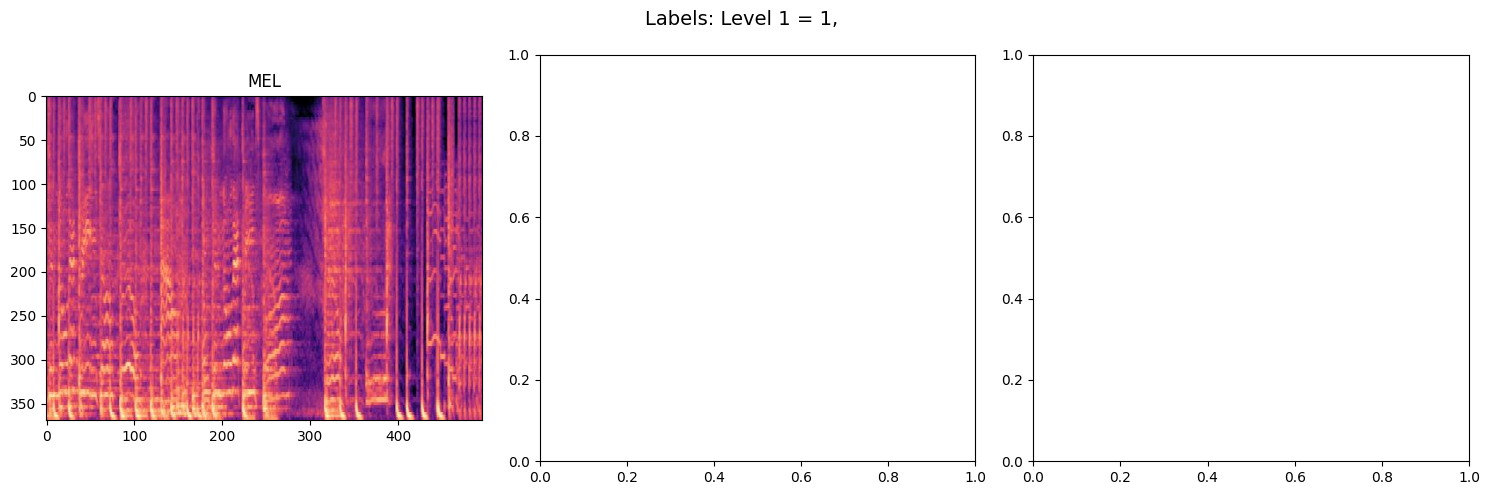

In [13]:
import matplotlib.pyplot as plt
example = ds["train"][4]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, (key, image) in zip(axs, [(k, example[k]) for k in ['mel']]):
    ax.imshow(image)
    ax.set_title(key.upper())
    #ax.axis('off')

# show labels in the plot title or below
fig.suptitle(f"Labels: Level 1 = {example['fst_level_label']}, "
             #f"Level 2 = {example['sec_level_label']}, "
             #f"Level 3 = {example['thr_level_label']}", 
             ,fontsize=14)

plt.tight_layout()
plt.show()

In [25]:
from pathlib import Path
import os
num_songs = 0
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\metal"
for path, subdirs, files in os.walk(root):
    for name in files:
        #print(os.path.join(path, name))
        num_songs += 1
print(num_songs)

29


In [75]:
from pathlib import Path
import os
from os import listdir
from os.path import isfile, join
num_songs = 0
songs_names = set([])
root = r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\classical"
for path, subdirs, files in os.walk(root):
   for name in files:
      songs_names.add(name)

In [76]:
songs_names

{'1-concerto_no.1_in_d_major_rv_2.mp3',
 '1-handel_trio_sonata_op._5_no.4.mp3',
 '1-ma_belle_si_ton_ame_(gilles_durant_de_la_bergerie).mp3',
 '1-matteis_ground_after_the_scotch_humour.mp3',
 '1-oxenford_(anon).mp3',
 '1-pandolfi_la_berbabea_op_4_#1.mp3',
 '1-prelude_(phalese).mp3',
 '1-preludio_i.mp3',
 '1-recercar_1.mp3',
 '1-set_a_6_in_c_major.mp3',
 '1-suite_iii_in_do_maggiore_-_prelude.mp3',
 '1-to_thee_we_sing_bulgarian_chant_tone_legetos.mp3',
 '1-we_are_guarded_by_the_cross.mp3',
 '1-widmung.mp3',
 '10-gigue.mp3',
 '10-guillarde_milanoise_(morlaye).mp3',
 '10-i_care_not_for_these_ladies_(thomas_campian).mp3',
 '10-johann_christian_bach_(arr_mozart)_concerto_in_d_k107_(1772).mp3',
 '10-partita_prima_in_mi_minore_-_double.mp3',
 '10-recercar_10_(steel_string_guitar).mp3',
 '10-sonata_iii_moderato.mp3',
 '10-tamerlano_act_ii_track_10.mp3',
 '10-waissel_polish_dance.mp3',
 '11-cesar_franck_sonata_for_violi.mp3',
 '11-christe.mp3',
 '11-fantasia.mp3',
 '11-fantasia_11.mp3',
 '11-gall

In [27]:
def get_num_songs(root):
    num_songs = 0
    for path, subdirs, files in os.walk(root):
        for name in files:
            #print(os.path.join(path, name))
            num_songs += 1
    print(num_songs)
    return num_songs


In [ ]:
metal_train = get_num_songs(r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\training\metal")
metal_eval = get_num_songs(r"P:\datasets\geenres\ismir04_genre\ismir04_genre\audio\evaluation\metal")

# 1517 artists dataset

In [1]:
import os
num_songs = 0
root = r"P:\datasets\geenres\1517\1517\1517_Artists"
for path, subdirs, files in os.walk(root):
    if len(subdirs) != 0:
        print(subdirs)
    for name in files:
        #print(os.path.join(path, name))
        num_songs += 1
print(num_songs)

['Alternative_and_Punk', 'Blues', 'Childrenss', 'Classical', 'Comedy_and_Spoken_Word', 'Country', 'Easy_Listening_and_Vocals', 'Electronic_and_Dance', 'Folk', 'Hip-Hop', 'Jazz', 'Latin', 'New_Age', 'Reggae', 'Religious', 'Rock_and_Pop', 'R_and_B_and_Soul', 'Soundtracks_and_More', 'World']
3181


In [4]:
import torchaudio
import numpy as np
import torch
import librosa
import soundfile as sf
from beat_this.preprocessing import LogMelSpect, load_audio
from pathlib import Path
def get_target_name(orig_path, target_folder):
    name = Path(orig_path).stem
    file_path =  os.path.join(target_folder, f"{name}.wav")
    return file_path

def preprocess_audio(path, target_sr = 22050, target_len = 30, start = 30):
    waveform, sr =load_audio(path)

# Extract 30–60s segment and average channels (convert to mono)
    max_length = target_len * sr
    start = start * sr
    waveform = waveform[start:start + max_length, :]  # shape: (samples, channels)
    waveform = waveform.mean(axis=1)  # shape: (samples,)

    # Convert to torch tensor with correct shape: (1, num_samples)
    waveform_reduced = librosa.resample(waveform, orig_sr=sr,target_sr=target_sr)
    return waveform_reduced

In [ ]:
target_sr = 22050
path = r"1517-Artists/Blues/Blue_Attitude-Stormy_Weather.mp3"
waveform_reduced = preprocess_audio(path)
sf.write("Blue_Attitude-Stormy_Weather_22.wav", waveform_reduced,target_sr)

In [29]:
from pathlib import Path
path = r"1517-Artists/Blues/Blue_Attitude-Stormy_Weather.mp3"
name = Path(path).stem
name

'Blue_Attitude-Stormy_Weather'

In [1]:
def get_target_name(orig_path, target_folder):
    name = Path(orig_path).stem
    file_path =  os.path.join(target_folder, f"{name}.wav")
    return file_path

In [5]:
import os 
target_folder = r"C:\Users\Marina\genres\1517-Artists_reduced"
folder = r"C:\Users\Marina\genres\1517-Artists\Blues"
genre = os.path.basename(folder)
target_folder = os.path.join(target_folder, genre)
target_sr = 22050

path = r"1517-Artists/Blues/Blue_Attitude-Stormy_Weather.mp3"
save_path = get_target_name(path, target_folder)
waveform_reduced = preprocess_audio(path)

sf.write(save_path, waveform_reduced,target_sr)

In [14]:
import librosa
import soundfile as sf
import soxr
reduced_sr = 22050
#waveform_reduced = soxr.resample(waveform, in_rate = sr, out_rate = 22050)
waveform_reduced = librosa.resample(waveform, orig_sr=sr,target_sr=reduced_sr)
sf.write("Alan_Fox_and_The_Shooters_Band-Lost_Without_Your_Love_22.wav", waveform_reduced,reduced_sr)

In [ ]:
import librosa
import soundfile as sf      # sanity check that the obtained files have proper resolution
import soxr
y, sr = librosa.load("1517-Artists_reduced/Blues/Blue_Attitude-Stormy_Weather.wav")

In [ ]:
y, sr = librosa.load("gtzan_old/gtzan_old/blues/blues.00000.wav") # gtzan has already sr 22050
sr

22050

In [13]:
import IPython.display as ipd
ipd.Audio(waveform_reduced, rate=22050)

In [21]:
root = r"C:\Users\Marina\genres\1517-Artists"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
subfolders

['C:\\Users\\Marina\\genres\\1517-Artists\\Alternative_and_Punk',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Blues',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Childrenss',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Classical',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Comedy_and_Spoken_Word',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Country',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Easy_Listening_and_Vocals',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Electronic_and_Dance',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Folk',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Hip-Hop',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Jazz',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Latin',
 'C:\\Users\\Marina\\genres\\1517-Artists\\New_Age',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Reggae',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Religious',
 'C:\\Users\\Marina\\genres\\1517-Artists\\Rock_and_Pop',
 'C:\\Users\\Marina\\genres\\1517-Artists\\R_and_B_and_Soul',
 'C:\\Users\\Marina\\genres\\1

In [32]:
import os 
from os import listdir
from os.path import isfile, join
from tqdm import tqdm

new_root = r"C:\Users\Marina\genres\1517-Artists_reduced"
root = r"C:\Users\Marina\genres\1517-Artists"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
#folder = 'C:\\Users\\Marina\\genres\\1517-Artists\\Blues'
for folder in subfolders:
    genre = os.path.basename(folder)
    if genre not in ['Childrenss','Religious', 'Comedy_and_Spoken_Word', 'Blues' ]:
        print(f" preprocessing {genre}")
        target_folder = os.path.join(new_root, genre)
        target_sr = 22050
        onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
        os.makedirs(target_folder, exist_ok = True)
        for file in tqdm(onlyfiles):
            path = os.path.join(folder, file)
            save_path = get_target_name(path, target_folder)
            #print(save_path)
            try:
                waveform_reduced = preprocess_audio(path)
                sf.write(save_path, waveform_reduced,target_sr)
            except Exception as e:
                print(f" skipping file {file} because it caused some problems")
                print(e)
           


 preprocessing Alternative_and_Punk


  0%|          | 0/182 [00:00<?, ?it/s]

 20%|██        | 37/182 [00:17<01:38,  1.48it/s]

 skipping file Cradles_Of_FIlth-Nymphetamine_Fix_Real.mp3 because it caused some problems
Could not load audio from "C:\Users\Marina\genres\1517-Artists\Alternative_and_Punk\Cradles_Of_FIlth-Nymphetamine_Fix_Real.mp3".


 48%|████▊     | 87/182 [00:40<00:54,  1.74it/s]

...

100%|██████████| 175/175 [01:28<00:00,  1.98it/s]


 skipping file Yoko_Shintaku-Take_Me_Out.mp3 because it caused some problems
Could not load audio from "C:\Users\Marina\genres\1517-Artists\R_and_B_and_Soul\Yoko_Shintaku-Take_Me_Out.mp3".
 preprocessing Soundtracks_and_More


100%|██████████| 150/150 [01:00<00:00,  2.50it/s]


 preprocessing World


100%|██████████| 158/158 [01:13<00:00,  2.16it/s]


In [40]:
audio_path = r"C:\Users\Marina\genres\1517-Artists_reduced\Blues\Ageing_hippie_groove_syndicate-Blues_for_Ben.wav"
waveform, sr = load_audio(audio_path)

In [42]:
sr

22050

In [33]:
def clean_genres(keys, dictionary):
    for key in keys:
        if key in dictionary:
            del dictionary[key]
    return dictionary

## visualizations

In [34]:
from os import listdir
from os.path import isfile, join
new_root  = r"C:\Users\Marina\genres\1517-Artists_reduced"
root = r"C:\Users\Marina\genres\1517-Artists"
genre_distributions = {}
subfolders = [ f.path for f in os.scandir(new_root) if f.is_dir() ]
for folder in subfolders:
    onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
    genre_distributions[folder.split("\\")[-1]] = len(onlyfiles)
genre_distributions = clean_genres(['Childrenss','Religious', 'Comedy_and_Spoken_Word' ], genre_distributions)

In [ ]:
from os import listdir    # finding the average duration of every genre in the dataset
from os.path import isfile, join
import librosa
import numpy
from tqdm import tqdm
genre_distribution_durations = {}
genres_to_omit = ['Childrenss','Religious', 'Comedy_and_Spoken_Word' ]
subfolders = [ f.path for f in os.scandir(new_root) if f.is_dir() ]
for folder in tqdm(subfolders):
    if folder not in genres_to_omit:
        onlyfiles = [f for f in listdir(folder) if isfile(join(folder, f))]
        durations = [librosa.get_duration(filename=join(folder, file)) for file in onlyfiles]
        genre_distribution_durations[folder.split("\\")[-1]] = numpy.average(durations)
genre_distribution_durations = clean_genres(genres_to_omit, genre_distribution_durations)

  0%|          | 0/19 [00:00<?, ?it/s]C:\Users\polin\AppData\Local\Temp\ipykernel_20744\3133061550.py:12: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  durations = [librosa.get_duration(filename=join(folder, file)) for file in onlyfiles]
100%|██████████| 19/19 [00:47<00:00,  2.49s/it]


In [34]:
import math
import numpy as np
genre_distribution_durations_sec = {key: float(np.round(value / 60, 3)) for key, value in genre_distribution_durations.items()}
genre_distribution_durations_sec["R&B_and_Soul"] = genre_distribution_durations_sec.pop("R_and_B_and_Soul")
genres_sec_sorted = {k: v for k, v in sorted(genre_distribution_durations_sec.items(), key=lambda item: item[1])}
genres_sec_sorted 

{'Soundtracks_and_More': 3.283,
 'Folk': 3.43,
 'Country': 3.443,
 'Latin': 3.68,
 'Hip-Hop': 3.763,
 'Easy_Listening_and_Vocals': 3.814,
 'Alternative_and_Punk': 3.834,
 'World': 3.906,
 'Reggae': 3.993,
 'Rock_and_Pop': 3.999,
 'Blues': 4.019,
 'Classical': 4.045,
 'R&B_and_Soul': 4.152,
 'New_Age': 4.407,
 'Jazz': 4.793,
 'Electronic_and_Dance': 5.081}

C:\Users\polin\AppData\Local\Temp\ipykernel_20744\1067348595.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_genres)


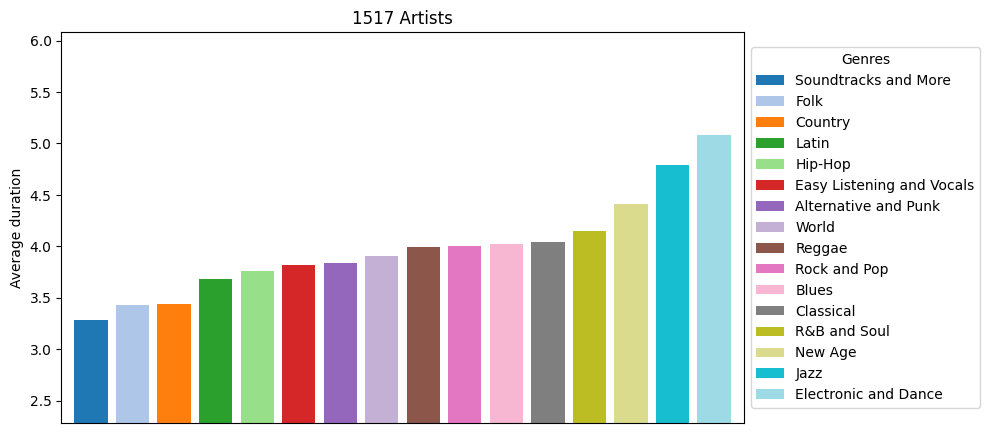

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch

# Example: replace with your actual data
# genres_sorted = {"Country": 185, "Folk": 182, ...}
names = [name.replace("_", " ") for name in genres_sec_sorted .keys()]
values = list(genres_sec_sorted .values())
num_genres = len(names)

# Generate colors
cmap = cm.get_cmap('tab20', num_genres)
colors = [cmap(i) for i in range(num_genres)]

# Plot
plt.figure(figsize=(10, 4.5))
x_pos = np.arange(num_genres)
bars = plt.bar(x_pos, values, color=colors)

# Hide x-axis labels
plt.xticks([])  # removes genre names below bars

# Set limits and labels
plt.ylim(min(values) - 1, max(values) + 1)
plt.ylabel("Average duration")
plt.title("1517 Artists")
plt.margins(x=0.02)

# Add legend on the side
legend_elements = [Patch(facecolor=colors[i], label=names[i]) for i in range(num_genres)]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Genres")

plt.tight_layout()
#plt.savefig("1517_artists_sec_average.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [35]:
genre_distributions["R&B_and_Soul"] = genre_distributions["R_and_B_and_Soul"]
genres_sorted = {k: v for k, v in sorted(genre_distributions.items(), key=lambda item: item[1])}
genres_sorted

{'Classical': 121,
 'Soundtracks_and_More': 150,
 'Hip-Hop': 151,
 'World': 158,
 'Latin': 160,
 'Electronic_and_Dance': 161,
 'New_Age': 165,
 'Reggae': 169,
 'R_and_B_and_Soul': 169,
 'R&B_and_Soul': 169,
 'Rock_and_Pop': 173,
 'Easy_Listening_and_Vocals': 174,
 'Jazz': 174,
 'Alternative_and_Punk': 179,
 'Folk': 184,
 'Country': 185,
 'Blues': 186}

In [36]:
genres_sorted["R&B_and_Soul"] = genres_sorted.pop("R_and_B_and_Soul")

C:\Users\Marina\AppData\Local\Temp\ipykernel_13004\3929193195.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_genres)


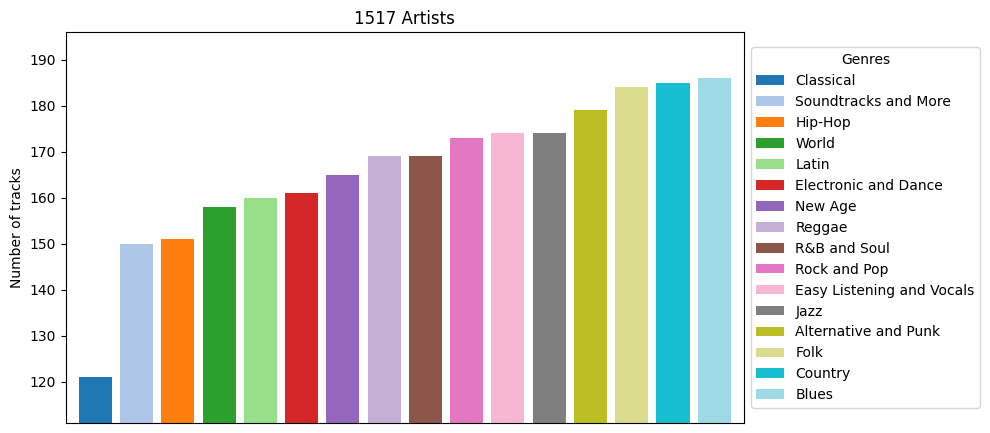

In [39]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch

# Example: replace with your actual data
# genres_sorted = {"Country": 185, "Folk": 182, ...}
names = [name.replace("_", " ") for name in genres_sorted.keys()]
values = list(genres_sorted.values())
num_genres = len(names)

# Generate colors
cmap = cm.get_cmap('tab20', num_genres)
colors = [cmap(i) for i in range(num_genres)]

# Plot
plt.figure(figsize=(10, 4.5))
x_pos = np.arange(num_genres)
bars = plt.bar(x_pos, values, color=colors)

# Hide x-axis labels
plt.xticks([])  # removes genre names below bars

# Set limits and labels
plt.ylim(min(values) - 10, max(values) + 10)
plt.ylabel("Number of tracks")
plt.title("1517 Artists")
plt.margins(x=0.02)

# Add legend on the side
legend_elements = [Patch(facecolor=colors[i], label=names[i]) for i in range(num_genres)]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Genres")

plt.tight_layout()
plt.savefig("1517_artists_vertical.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [6]:
songs_names = set([])
root = r"P:\datasets\geenres\1517\1517\1517_Artists\Classical"
for path, subdirs, files in os.walk(root):
   for name in files:
      songs_names.add(name)

getting corresponding artist for each track 

In [11]:
import os
from mutagen.easyid3 import EasyID3 
artists = {} 
for filename in os.listdir(root):
    if filename.lower().endswith(".mp3"):
        file_path = os.path.join(root, filename)
        try:
            audio = EasyID3(file_path)
            artist = audio.get('artist', ['Unknown'])[0]
            artists.setdefault(artist, []).append(filename)
            #print(f"{filename} → {artist}")
        except Exception as e:
            print(f"Error reading {filename}: {e}")

In [24]:
artists

{'A.A.Owen': ['A.A.Owen-Blue_Queen-Prologue.mp3',
  'A.A.Owen-Mysteries_1.mp3',
  'A.A.Owen-The_Dancer.mp3'],
 'Aleksandr Tsiboulski': ['Aleksandr_Tsiboulski-Enrique_Granados-Spanish_dance_No.5.mp3',
  'Aleksandr_Tsiboulski-Issaac_Albeniz-Zambra_Granadina.mp3'],
 'Amael Piano Trio': ['Amael_Piano_Trio-J._Brahms-Allegro_moltoTrio_C_minor.mp3'],
 'Andrei Krylov': ['Andrei_Krylov-Al_Hamra.mp3',
  'Andrei_Krylov-Autumn.mp3',
  'Andrei_Krylov-Blezard.mp3',
  'Andrei_Krylov-In_the_Ocean.mp3',
  'Andrei_Krylov-Kings_Bosa-Nova.mp3',
  'Andrei_Krylov-Love_song.mp3',
  'Andrei_Krylov-Margarita.mp3',
  'Andrei_Krylov-Melancholy.mp3',
  'Andrei_Krylov-Memories_of_Love.mp3',
  'Andrei_Krylov-Moon_Gypsy.mp3',
  'Andrei_Krylov-Portret_of_Soul.mp3',
  'Andrei_Krylov-Romance.mp3',
  'Andrei_Krylov-Sunrise_meditation.mp3',
  'Andrei_Krylov-Sunset_Meditation.mp3'],
 'andrys': ['andrys-Beethoven_Moonlight_Sonata_i.mp3',
  'andrys-Chopin_Prelude_No._20_in_c_minor.mp3',
  'andrys-Rachmaninov_Prelude_Op_23_N

In [23]:
artists_len = {key: len(artists[key]) for key, value in artists.items()}  # getting counts for each artist


In [ ]:
import pandas as pd     # creating a df with all information about the 1517 tracks
header = ["title",  "genre", "artist", "filepath"]
dataset_table =dict((el,[]) for el in header)
root = r"P:\datasets\geenres\1517\1517\1517_Artists"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
for folder in subfolders:
    genre = folder.split("\\")[-1]
    for f in listdir(folder) :
        file = join(folder, f)
        if isfile(file):
            dataset_table["title"].append(f)
            dataset_table["filepath"].append(file)
            dataset_table["genre"].append(genre)
            audio = EasyID3(file)
            artist = audio.get('artist', ['Unknown'])[0]
            dataset_table["artist"].append(artist)


In [32]:
dataset_df = pd.DataFrame.from_dict(dataset_table)
dataset_df.tail(20)
dataset_df.to_csv("1517_artist.csv")

making a split so that the it it homogeneous by genre and the tracks of the same artists end up in the same split


In [40]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
df = pd.read_csv("1517_artist.csv")
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# First split into train+val vs test (e.g. 80/20)
for trainval_idx, test_idx in sgkf.split(df, df['genre'], groups=df['artist']):
    df_trainval = df.iloc[trainval_idx]
    df_test = df.iloc[test_idx]
    break
for train_idx, val_idx in sgkf.split(df_trainval, df_trainval['genre'], groups=df_trainval['artist']):
    df_train = df_trainval.iloc[train_idx]
    df_val = df_trainval.iloc[val_idx]
    break
df_test.head()


,Unnamed: 0,title,genre,artist,filepath
23,23,Bright_Eyes-From_a_Balance_Beam.mp3,Alternative_and_Punk,Bright Eyes,P:\datasets\geenres\1517\1517\1517_Artists\Alt...
24,24,Bright_Eyes-Going_for_the_Gold.mp3,Alternative_and_Punk,Bright Eyes,P:\datasets\geenres\1517\1517\1517_Artists\Alt...
25,25,Bright_Eyes-Gold_Mine_Gutted.mp3,Alternative_and_Punk,Bright Eyes,P:\datasets\geenres\1517\1517\1517_Artists\Alt...
26,26,Bright_Eyes-Lover_I_Dont_Have_to_Love.mp3,Alternative_and_Punk,Bright Eyes,P:\datasets\geenres\1517\1517\1517_Artists\Alt...
27,27,Bright_Eyes-Something_Vague.mp3,Alternative_and_Punk,Bright Eyes,P:\datasets\geenres\1517\1517\1517_Artists\Alt...


In [ ]:
artist_train =set( dict(df_train["artist"].value_counts()).keys())
artist_val = set(dict(df_val["artist"].value_counts()).keys())
artist_test = set(dict(df_test["artist"].value_counts()).keys())
# checking if there is any intersection between splits in terms of artists
intersection =bool (artist_test & artist_train or artist_train & artist_val or artist_val & artist_test) 
intersection

False

In [ ]:
# checking if genre distribution is homogeneous
print("Train genre dist:\n", df_train['genre'].value_counts()) 
print("Val genre dist:\n", df_val['genre'].value_counts())
print("Test genre dist:\n", df_test['genre'].value_counts())

Train genre dist:
 genre
R_and_B_and_Soul             131
Reggae                       123
Childrenss                   123
Folk                         116
Rock_and_Pop                 112
Hip-Hop                      112
Country                      112
Jazz                         111
Blues                        111
Easy_Listening_and_Vocals    108
Alternative_and_Punk         107
New_Age                      107
World                        102
Comedy_and_Spoken_Word        98
Latin                         98
Electronic_and_Dance          97
Classical                     94
Soundtracks_and_More          92
Religious                     84
Name: count, dtype: int64
Val genre dist:
 genre
Folk                         42
Blues                        41
Soundtracks_and_More         40
New_Age                      39
Religious                    37
Alternative_and_Punk         36
Latin                        31
Rock_and_Pop                 28
World                        25
R_and_B_and

# FMA dataset

In [61]:
import pandas as pd
dataset_table = pd.read_csv(r"P:\datasets\geenres\fma\fma_small\fma_small\tracks_small_filtered.csv")
dataset_table.head()

,Unnamed: 0.1,Unnamed: 0,track_id,title,title.1,genre_top,duration
0,0,0,2,AWOL - A Way Of Life,Food,Hip-Hop,168
1,1,1,5,AWOL - A Way Of Life,This World,Hip-Hop,206
2,2,2,10,Constant Hitmaker,Freeway,Pop,161
3,3,3,140,The Blind Spot,Queen Of The Wires,Folk,253
4,4,4,141,Every Man For Himself,Ohio,Folk,182


In [66]:
genres = list(dataset_table["genre_top"].unique())
genres

['Hip-Hop',
 'Pop',
 'Folk',
 'Experimental',
 'Rock',
 'International',
 'Electronic',
 'Instrumental']

In [106]:
import os # sorting fma to be in folders by genres
import shutil
from tqdm import tqdm
target_root = r"P:\datasets\geenres\fma\fma_sorted"
root = r"P:\datasets\geenres\fma\fma_small\fma_small"
#genre = 'Hip-Hop'
genres = list(dataset_table["genre_top"].unique())
for genre in genres:
    print(f"sorting {genre}")
    target_folder = os.path.join(target_root, genre)
    os.makedirs(target_folder, exist_ok = True)
    df_fltered = dataset_table[dataset_table["genre_top"] == genre]
    ids_genre  = df_fltered["track_id"].unique()
    subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
    subfolders_dict = {int(f.split("\\")[-1] + "000"): f for f in subfolders}
    for id in tqdm(ids_genre):
        key_prev  = None
        for key, values in subfolders_dict.items():
            if id < key:
                num_zeros = 6 - len(str(id)) 
                name = f"{'0'*num_zeros}{id}.mp3"
                orig_path = os.path.join(subfolders_dict[key_prev],name)
                new_path = os.path.join(target_folder, name)
                # print(orig_path)
                # print(new_path)
                shutil.copyfile(orig_path, new_path)
                break
            else:
                key_prev = key
    #print(target_folder)
#df_fltered.head()

sorting Hip-Hop


  0%|          | 0/989 [00:00<?, ?it/s]

100%|██████████| 989/989 [00:04<00:00, 203.13it/s]


sorting Pop


100%|██████████| 986/986 [00:04<00:00, 227.97it/s]


...

100%|██████████| 998/998 [00:06<00:00, 152.06it/s]


sorting Electronic


100%|██████████| 992/992 [00:10<00:00, 94.53it/s] 


sorting Instrumental


100%|██████████| 1000/1000 [00:10<00:00, 94.46it/s]


In [68]:
import os
target_root = r"P:\datasets\geenres\fma\fma_sorted"
genre = 'Hip-Hop'
target_folder = os.path.join(target_root, genre)
os.makedirs(target_folder, exist_ok = True)
df_fltered = dataset_table[dataset_table["genre_top"] == genre]
df_fltered.head()

,Unnamed: 0.1,Unnamed: 0,track_id,title,title.1,genre_top,duration
0,0,0,2,AWOL - A Way Of Life,Food,Hip-Hop,168
1,1,1,5,AWOL - A Way Of Life,This World,Hip-Hop,206
35,35,35,676,Change Thoughts (radio edit),The Tension,Hip-Hop,197
37,37,37,694,mp3 single with Faust,Planet Say (featuring Faust),Hip-Hop,291
38,38,38,695,Cock Rock Disco 2006 Free Compilation,Elephants,Hip-Hop,104


In [ ]:
ids_genre  = df_fltered["track_id"].unique()
ids_genre

In [83]:
root = r"P:\datasets\geenres\fma\fma_small\fma_small"
subfolders = [ f.path for f in os.scandir(root) if f.is_dir() ]
subfolders_dict = {int(f.split("\\")[-1] + "000"): f for f in subfolders}
subfolders_dict

{0: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\000',
 1000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\001',
 2000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\002',
 3000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\003',
 4000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\004',
 5000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\005',
 6000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\006',
 7000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\007',
 8000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\008',
 9000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\009',
 10000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\010',
 11000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\011',
 12000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\012',
 13000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\013',
 14000: 'P:\\datasets\\geenres\\fma\\fma_small\\fma_small\\014',
 15000: 'P:\\datasets\\geenres\\fma\\f

In [100]:
num_digits = len(str(id))
num_digits

3

In [102]:
import shutil
from tqdm import tqdm
for id in tqdm(ids_genre):
    for key, values in subfolders_dict.items():
        if id <= key:
            num_zeros = 6 - len(str(id)) 
            name = f"{'0'*num_zeros}{id}.mp3"
            orig_path = os.path.join(subfolders_dict[key_prev],name)
            new_path = os.path.join(target_folder, name)
            print(orig_path)
            print(new_path)
            shutil.copyfile(orig_path, new_path)
            break
        else:
            key_prev = key
    


 10%|▉         | 97/989 [00:00<00:01, 470.23it/s]

P:\datasets\geenres\fma\fma_small\fma_small\000\000002.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000002.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000005.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000005.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000676.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000676.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000694.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000694.mp3
P:\datasets\geenres\fma\fma_small\fma_small\000\000695.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\000695.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004682.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\004682.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004684.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\004684.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004685.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\004685.mp3
P:\datasets\geenres\fma\fma_small\fma_small\004\004688.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

 15%|█▍        | 145/989 [00:00<00:01, 463.40it/s]

P:\datasets\geenres\fma\fma_small\fma_small\013\013735.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013735.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013747.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013747.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013748.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013748.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013749.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013749.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013767.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013767.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013768.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013768.mp3
P:\datasets\geenres\fma\fma_small\fma_small\013\013804.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\013804.mp3
P:\datasets\geenres\fma\fma_small\fma_small\014\014363.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\014363.mp3
P:\datasets\geenres\fma\fma_small\fma_small\014\014365.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

 24%|██▍       | 237/989 [00:00<00:01, 420.40it/s]

...

P:\datasets\geenres\fma\fma_small\fma_small\136\136465.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136465.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136466.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136466.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136467.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136467.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136468.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136468.mp3
P:\datasets\geenres\fma\fma_small\fma_small\136\136469.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\136469.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137895.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\137895.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137896.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\137896.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137898.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\137898.mp3
P:\datasets\geenres\fma\fma_small\fma_small\137\137899.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

 95%|█████████▌| 944/989 [00:02<00:00, 321.99it/s]

P:\datasets\geenres\fma\fma_small\fma_small\144\144213.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144213.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144214.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144214.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144215.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144215.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144216.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144216.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144740.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144740.mp3
P:\datasets\geenres\fma\fma_small\fma_small\144\144741.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\144741.mp3
P:\datasets\geenres\fma\fma_small\fma_small\145\145724.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\145724.mp3
P:\datasets\geenres\fma\fma_small\fma_small\145\145727.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\145727.mp3
P:\datasets\geenres\fma\fma_small\fma_small\145\145728.mp3
P:\datasets\geenres\fma\fma_sorted\Hi

100%|██████████| 989/989 [00:02<00:00, 360.04it/s]

P:\datasets\geenres\fma\fma_small\fma_small\149\149690.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\149690.mp3
P:\datasets\geenres\fma\fma_small\fma_small\149\149951.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\149951.mp3
P:\datasets\geenres\fma\fma_small\fma_small\149\149953.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\149953.mp3
P:\datasets\geenres\fma\fma_small\fma_small\150\150287.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\150287.mp3
P:\datasets\geenres\fma\fma_small\fma_small\150\150288.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\150288.mp3
P:\datasets\geenres\fma\fma_small\fma_small\152\152543.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\152543.mp3
P:\datasets\geenres\fma\fma_small\fma_small\152\152545.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\152545.mp3
P:\datasets\geenres\fma\fma_small\fma_small\153\153337.mp3
P:\datasets\geenres\fma\fma_sorted\Hip-Hop\153337.mp3
P:\datasets\geenres\fma\fma_small\fma_small\154\154303.mp3
P:\datasets\geenres\fma\fma_sorted\Hi